# Data Audit

**Author**: Nikolas Antoniou<br>
**Project**: Retail shop Analytics

This notebook focuses on the inspection of the data in order to be able to identify all the issues that may exist. After that, the aim is to clean and transform the dataset in order to be suitable for analysis and modelling.

___________

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns 
from scipy import stats 

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

print("The libs have been successfully loaded")

The libs have been successfully loaded


#### Loading the Data

In [4]:
CSV_Path = "../data/inventoryANDsales2025.csv"

In [5]:
df = pd.read_csv(CSV_Path)

In [7]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

Shape: 3,500 rows × 12 columns



In [6]:
df.head()

,Id,name,season,price,product_category,size,quantity,quantities_sold,collection_family,sex,color,discount
0,WP-00001,Morgex Quilted Pants,SS25,102.9900,Pants,S,542,56,Morgex,Women,Forest Green,0
1,WM-00001,Tribe Quilted Shirt,SS25,109.9900,Shirt,XL,443,155,Tribe,Women,Forest Green,0
2,WL-00001,Box Logo Stretch Sweatshirt,FS24,121.9900,Sweatshirt,S,59,85,Box Logo,Women,Grey Melange,20
3,S-00001,Morgex Print T-Shirt,FS24,39.9900,T-Shirt,L,35,305,Morgex,Men,White Whisper,25
4,P-00001,Tribe Graphic Pants,SS25,118.9900,Pants,XXL,63,58,Tribe,Men,Green Lichen,0


In [8]:
df.columns

Index(['Id', 'name', 'season', 'price', 'product_category', 'size', 'quantity',
       'quantities_sold', 'collection_family', 'sex', 'color', 'discount'],
      dtype='object')

_______________

## Research Hypotheses

### Dataset Structure
The dataset contains **12 attributes** spanning product identity, categorization, pricing, inventory, and sales performance. Several rows represent the same product across different sizes, creating a **one-product-many-rows** structure that must be collapsed before modeling.

---

### H1 — Size Demand Distribution by Category
**Goal:** Identify the 2–3 best-selling sizes per product category to inform inventory allocation.  
**Rationale:** Consumer anthropometrics vary significantly by geography and demographics. Operating in Cyprus — a Mediterranean market — size distributions are expected to skew toward smaller-to-medium ranges (S/M/38–42) compared to Northern European markets (DE, NL, SE). Stocking misaligned sizes leads to dead inventory and lost sales.  
**Method:** Group by `product_category` + `size`, aggregate `quantities_sold`, rank within group, extract top-k sizes.

---

### H2 — Color Preference & Collection Planning
**Goal:** Determine which colors drive the highest sales volume to guide future collection sourcing.  
**Rationale:** Color preference is a strong purchase driver in fashion retail and correlates with seasonal trends and cultural context. Identifying top-performing colors allows the buyer to replicate successful palettes in future collections.  
**Method:** Group by `color`, aggregate `quantities_sold`, visualize distribution. Cross-tab with `season` and `product_category` for deeper segmentation.

---

### H3 — Discount Effect on Sales Performance
**Goal:** Quantify whether discounted products outperform non-discounted equivalents in units sold.  
**Rationale:** Blanket discounting erodes margins without guaranteed volume uplift. A data-driven discount policy requires evidence of a statistically significant lift in `quantities_sold` for discounted SKUs.  
**Method:** Binary segmentation on `discount` > 0. Compare `quantities_sold` distributions between groups using a Mann-Whitney U test (non-parametric, appropriate if normality is not confirmed). Effect size via Cohen's d or rank-biserial correlation.

---

### Data Transformation Required
Before any analysis, the dataset must be **collapsed from SKU-level to product-level**:
- Aggregate `size` values into an ordered tuple per product (`Id` / `name`)
- Aggregate `quantities_sold` into a corresponding tuple (positionally aligned to sizes)
- Retain scalar attributes (`price`, `product_category`, `collection_family`, `season`, `sex`, `color`, `discount`) as-is after verifying they are constant within each product group

This reduction will significantly decrease row count and enable product-level comparisons.

_______________

## Audit

In [9]:
# shape, data types and memory
print("─SHAPE-")
print(f"  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

print("\n─DTYPES & MEMORY-")
info = pd.DataFrame({
    "dtype":   df.dtypes,
    "non_null": df.notnull().sum(),
    "null":     df.isnull().sum(),
    "memory_KB": df.memory_usage(deep=True)[1:] / 1024
})
display(info.style.background_gradient(subset=["null"], cmap="Reds"))

print(f"\nTotal memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")


─SHAPE-
  Rows: 3,500   Columns: 12

─DTYPES & MEMORY-


,dtype,non_null,null,memory_KB
Id,object,3500,0,223.641602
name,object,3500,0,261.991211
season,object,3500,0,208.496094
price,float64,3500,0,27.343750
product_category,object,3500,0,218.329102
size,object,3500,0,202.215820
quantity,int64,3500,0,27.343750
quantities_sold,int64,3500,0,27.343750
collection_family,object,3500,0,219.179688
sex,object,3500,0,208.181641



Total memory: 1880.34 KB


In [10]:
# missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
completeness = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
completeness = completeness[completeness["missing_count"] > 0].sort_values("missing_%", ascending=False)

if completeness.empty:
    print("✓ No missing values detected.")
else:
    display(completeness)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
    ax.set_title("Missing Values Heatmap (yellow = missing)")
    plt.tight_layout()
    plt.savefig("figures/01_missing_heatmap.png", dpi=150)
    plt.show()

✓ No missing values detected.


In [11]:
# duplicates
n_full_dupes = df.duplicated().sum()
n_id_dupes   = df.duplicated(subset=["Id"]).sum()  # same Id, different size rows are expected
n_name_dupes = df.duplicated(subset=["name", "size"]).sum()

print(f"Fully duplicate rows      : {n_full_dupes:,}")
print(f"Duplicate (Id only)       : {n_id_dupes:,}   ← expected (multi-size products)")
print(f"Duplicate (name + size)   : {n_name_dupes:,}  ← these are true duplicates")

if n_name_dupes > 0:
    display(df[df.duplicated(subset=["name", "size"], keep=False)].sort_values("name").head(20))

Fully duplicate rows      : 0
Duplicate (Id only)       : 0   ← expected (multi-size products)
Duplicate (name + size)   : 1,564  ← these are true duplicates


,Id,name,season,price,product_category,size,quantity,quantities_sold,collection_family,sex,color,discount
1658,WBackpackBoxLogo-0001,Box Logo Backpack,SS25,96.9900,Accessories,One Size,436,159,Box Logo,Women,Old Rose,0
2972,BackpackBoxLogo-0002,Box Logo Backpack,SS25,102.9900,Accessories,One Size,305,278,Box Logo,Men,White Whisper,0
2950,BackpackBoxLogo-0001,Box Logo Backpack,FS24,69.9900,Accessories,One Size,21,108,Box Logo,Men,Free Blue,40
1085,BeanieBoxLogo-0001,Box Logo Beanie,FS24,61.9900,Accessories,One Size,66,116,Box Logo,Men,Old Rose,15
1999,BeanieBoxLogo-0002,Box Logo Beanie,FS24,31.9900,Accessories,One Size,63,409,Box Logo,Men,Caviar,20
26,BeltBoxLogo-0001,Box Logo Belt,SS25,72.9900,Accessories,One Size,455,120,Box Logo,Men,Olive,0
2064,BeltBoxLogo-0004,Box Logo Belt,FS24,107.9900,Accessories,One Size,9,34,Box Logo,Men,Snow White,20
2526,BeltBoxLogo-0005,Box Logo Belt,FS24,111.9900,Accessories,One Size,46,468,Box Logo,Men,Navy,50
716,BeltBoxLogo-0002,Box Logo Belt,SS25,102.9900,Accessories,One Size,396,107,Box Logo,Men,Old Rose,0
1849,BeltBoxLogo-0003,Box Logo Belt,SS25,69.9900,Accessories,One Size,229,249,Box Logo,Men,Burgundy,0


In [12]:
print("Whitespace check\n")

str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    has_ws = df[col].dropna().str.contains(r"^\s|\s$").any()
    print(f"  {col:<25} leading/trailing whitespace: {has_ws}")

Whitespace check

  Id                        leading/trailing whitespace: False
  name                      leading/trailing whitespace: False
  season                    leading/trailing whitespace: False
  product_category          leading/trailing whitespace: False
  size                      leading/trailing whitespace: False
  collection_family         leading/trailing whitespace: False
  sex                       leading/trailing whitespace: False
  color                     leading/trailing whitespace: False


In [13]:
print("Consistency\n")

for col in str_cols:
    vals = df[col].dropna().unique()
    lower_set = {v.strip().lower() for v in vals}
    if len(lower_set) < len(vals):
        print(f"  {col}: mixed casing detected → apply .str.strip().str.title()")
    else:
        print(f"  {col}: ✓")

Consistency

  Id: ✓
  name: ✓
  season: ✓
  product_category: ✓
  size: ✓
  collection_family: ✓
  sex: ✓
  color: ✓


In [14]:
print("Data type conversion canditates\n")

for col in str_cols:
    if pd.to_numeric(df[col], errors="coerce").notna().mean() > 0.9:
        print(f"  '{col}': stored as string but looks numeric → pd.to_numeric()")
    unique_vals = set(df[col].dropna().str.strip().str.lower().unique())
    if unique_vals <= {"true","false","yes","no","1","0","y","n"}:
        print(f"  '{col}': looks boolean → map to bool")

print("SEASON VALUES-")
print(df["season"].value_counts())
print("\n─SEX VALUE─")
print(df["sex"].value_counts())
print("\nSIZE VALUES─")
print(df["size"].value_counts().sort_index())

Data type conversion canditates

SEASON VALUES-
season
FS24    1755
SS25    1745
Name: count, dtype: int64

─SEX VALUE─
sex
Men      1911
Women    1589
Name: count, dtype: int64

SIZE VALUES─
size
36           19
37           21
38           14
39           18
40           36
41           41
42           36
43           31
44           20
45           22
46           15
L           478
M           533
One Size    274
S           520
XL          463
XS          503
XXL         456
Name: count, dtype: int64


In [15]:
# validity check
findings = []

# Price must be positive
invalid_price = df[df["price"] <= 0]
findings.append(("price <= 0", len(invalid_price)))

# Quantity and quantities_sold must be non-negative
invalid_qty = df[df["quantity"] < 0]
invalid_sold = df[df["quantities_sold"] < 0]
findings.append(("quantity < 0", len(invalid_qty)))
findings.append(("quantities_sold < 0", len(invalid_sold)))

# quantities_sold cannot exceed quantity (can't sell more than you have)
oversold = df[df["quantities_sold"] > df["quantity"]]
findings.append(("quantities_sold > quantity", len(oversold)))

# Discount must be between 0 and 1 (or 0–100 depending on encoding)
if df["discount"].max() <= 1:
    invalid_disc = df[(df["discount"] < 0) | (df["discount"] > 1)]
    findings.append(("discount outside [0,1]", len(invalid_disc)))
else:
    invalid_disc = df[(df["discount"] < 0) | (df["discount"] > 100)]
    findings.append(("discount outside [0,100]", len(invalid_disc)))

# sex must be known values
valid_sex = {"male", "female", "unisex", "m", "f", "u"}
invalid_sex = df[~df["sex"].str.strip().str.lower().isin(valid_sex)]
findings.append(("sex — unexpected value", len(invalid_sex)))

validity_df = pd.DataFrame(findings, columns=["Rule Violation", "Count"])
validity_df["Status"] = validity_df["Count"].apply(lambda x: "✓ OK" if x == 0 else "⚠ ISSUE")
display(validity_df)

,Rule Violation,Count,Status
0,price <= 0,0,✓ OK
1,quantity < 0,0,✓ OK
2,quantities_sold < 0,0,✓ OK
3,quantities_sold > quantity,1929,⚠ ISSUE
4,"discount outside [0,100]",0,✓ OK
5,sex — unexpected value,3500,⚠ ISSUE


─DESCRIPTIVE STATISTICS─


,count,mean,std,min,25%,50%,75%,max
price,3500.0000,99.1650,37.1640,19.9900,70.9900,95.9900,125.9900,208.9900
quantity,3500.0000,151.3230,122.5800,2.0000,53.0000,115.0000,221.2500,561.0000
quantities_sold,3500.0000,168.9660,128.3320,2.0000,60.0000,137.0000,254.0000,577.0000
discount,3500.0000,11.9390,13.8000,0.0000,0.0000,10.0000,25.0000,50.0000



─OUTLIER DETECTION (IQR + Z-score)─


,IQR_outliers,Z_outliers,skewness
column,,,
price,5,0,0.3520
quantity,57,13,1.0060
quantities_sold,11,5,0.8200
discount,0,0,0.8050


\)DISTRIBUTION PLOTS─


<function matplotlib.pyplot.show(close=None, block=None)>

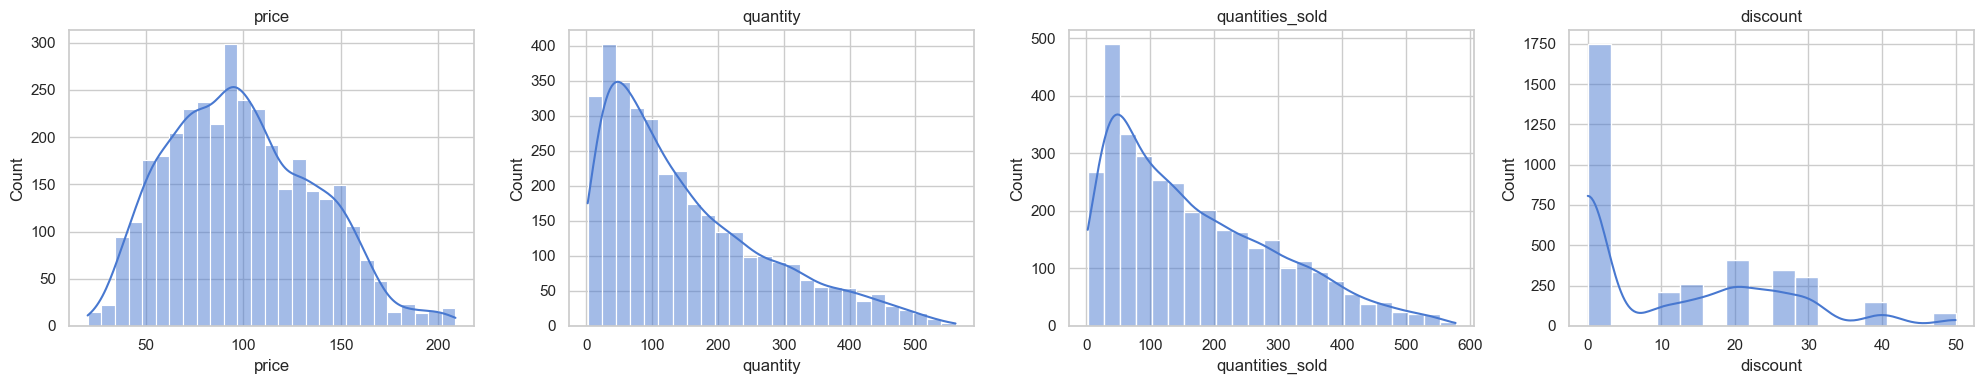

In [16]:
# accuracy inspection
num_cols = df.select_dtypes(include=np.number).columns

print("─DESCRIPTIVE STATISTICS─")
display(df[num_cols].describe().T.round(3))

print("\n─OUTLIER DETECTION (IQR + Z-score)─")
outlier_rows = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    iqr_out = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    z_out   = int((np.abs(stats.zscore(s)) > 3).sum())
    skew    = round(float(s.skew()), 3)
    outlier_rows.append({"column": col, "IQR_outliers": iqr_out, "Z_outliers": z_out, "skewness": skew})

display(pd.DataFrame(outlier_rows).set_index("column"))

print("\)DISTRIBUTION PLOTS─")
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/02_distributions.png", dpi=150)
plt.show

In [18]:
# audit summary
summary = {
    "Completeness"  : f"{(1 - df.isnull().mean().mean()) * 100:.1f}% complete",
    "Uniqueness"    : f"{n_full_dupes} full dupes | {n_name_dupes} (name+size) dupes",
    "Consistency"   : "Check Cell 8 output",
    "Validity"      : f"{validity_df[validity_df['Count']>0]['Rule Violation'].tolist()}",
    "Accuracy"      : "Check outlier table in Cell 10"
}

print("═AUDIT SUMMARY═")
for dim, result in summary.items():
    print(f"  {dim:<15} {result}")

═AUDIT SUMMARY═
  Completeness    100.0% complete
  Uniqueness      0 full dupes | 1564 (name+size) dupes
  Consistency     Check Cell 8 output
  Validity        ['quantities_sold > quantity', 'sex — unexpected value']
  Accuracy        Check outlier table in Cell 10
